# EDA — Acciones Argentinas

Universo: **67 empresas** — las 66 de `dim_empresa.mercado='argentina_local'` (panel BYMA/Merval) + **Vista Energy (`VIST`)**.

**Nota sobre Vista**: Yahoo la clasifica con `pais_origen='Mexico'` porque está constituida legalmente como SAB de C.V. mexicana (tema impositivo), pero el negocio es prácticamente 100% Vaca Muerta — mismo tipo de dato torcido que encontramos con STNE/PAGS/XYZ (sector), acá en país. Se incluye igual, con esta aclaración, sin tocar `correcciones_sector.py` (esto es `pais_origen`, no `sector`, y es un caso único — no se arma un mecanismo nuevo por una sola excepción).

## Foco: brecha cambiaria implícita

**13 de las 67 cotizan al mismo tiempo en BYMA (ARS) y como ADR directo en NYSE (USD)** — misma empresa, dos precios, dos monedas. Eso permite estimar un tipo de cambio implícito (al estilo CCL) **sin necesitar el ratio de conversión del ADR**: trabajando con *retornos* en vez de niveles, el ratio (constante) se cancela matemáticamente.

$$\frac{ADR_{t2}}{ADR_{t1}} = \frac{Local_{t2}}{Local_{t1}} \times \frac{CCL_{t1}}{CCL_{t2}} \quad\Rightarrow\quad \text{crecimiento del CCL implícito} = \frac{\text{crecimiento del precio local (ARS)}}{\text{crecimiento del precio ADR (USD)}}$$

Comparando ese crecimiento implícito contra el crecimiento del dólar oficial (`USDARS` en `fact_macro_daily`) se obtiene la brecha — en qué medida el "dólar de mercado" implícito en cada acción se movió distinto al oficial. **No calculamos el nivel absoluto** (eso sí necesitaría el ratio real de cada ADR, y no encontré una fuente confiable para los 13 — preferí no inventar un número antes que mostrar un nivel potencialmente mal calculado).

El precio ADR no está en el warehouse (`ticker_adr_usa` es solo metadata, el pipeline nunca lo pidió) — se baja acá mismo, ad-hoc, con su propio cache en disco (`cache/adr_argentina/`), sin tocar `fact_precios_daily` ni el pipeline diario.

In [1]:
import time
from pathlib import Path

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

con = duckdb.connect("../data/warehouse.duckdb", read_only=True)

local = con.execute("SELECT * FROM dim_empresa WHERE mercado = 'argentina_local'").fetchdf()
vista = con.execute("SELECT * FROM dim_empresa WHERE ticker_usd = 'VIST'").fetchdf()
vista["pais_origen_real"] = "Argentina (Vaca Muerta) — pais_origen de Yahoo dice Mexico por domicilio legal"
dim_arg = pd.concat([local, vista], ignore_index=True)
ARG = dim_arg["ticker_usd"].tolist()

metrics = con.execute("SELECT * FROM fact_metrics_daily WHERE ticker_usd = ANY(?)", [ARG]).fetchdf()

print(f"Universo: {len(ARG)} empresas ({len(local)} BYMA/Merval + Vista)")
print("dim_arg:", dim_arg.shape)
print("fact_metrics_daily:", metrics.shape)

Universo: 67 empresas (66 BYMA/Merval + Vista)
dim_arg: (67, 15)
fact_metrics_daily: (269, 29)


## 1. Overview del subuniverso

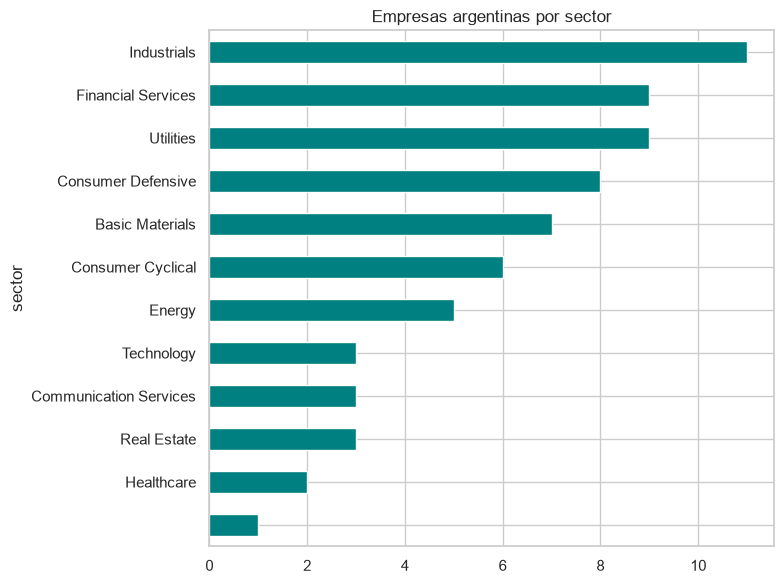

,ticker_usd,nombre_empresa,sector,ticker_adr_usa,market_cap,pe_trailing,dividend_yield_pct
65,YPFD,Ypf,Energy,YPF,3.162085e+13,30.35,0.00
34,GGAL,Grupo Financiero Galicia S.A,Financial Services,GGAL,9.388553e+12,46.80,5.28
60,TECO2,Telecom Argentina,Communication Services,TEO,8.184015e+12,10.59,0.36
6,BMA,Banco Macro,Financial Services,BMA,6.713598e+12,15.36,8.76
54,PAMP,Pampa Energía,Industrials,PAM,6.670319e+12,8.09,0.00
...,...,...,...,...,...,...,...
59,DOME,Suscripción Preferente Domec S.A,Consumer Cyclical,nan,8.000000e+09,NaN,0.00
66,VIST,Vista Oil & Gas Sab De,Energy,nan,7.107168e+09,8.50,0.00
39,ROSE,Instituto Rosenbusch,Healthcare,nan,5.983820e+09,0.71,0.00
55,POLL,Polledo,Industrials,nan,1.958220e+09,NaN,0.00


In [2]:
ultimo = metrics.sort_values("fecha").groupby("ticker_usd").last().reset_index()
overview = dim_arg.merge(ultimo, on="ticker_usd", how="left")[
    ["ticker_usd", "nombre_empresa", "sector", "ticker_adr_usa", "market_cap", "pe_trailing", "dividend_yield_pct"]
].sort_values("market_cap", ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
dim_arg["sector"].value_counts().plot(kind="barh", ax=ax, color="teal")
ax.set_title("Empresas argentinas por sector")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

overview

## 2. Valuación vs. sector (capa Gold)

In [3]:
comparables_arg = con.execute("SELECT * FROM gold_comparables WHERE ticker_usd = ANY(?)", [ARG]).fetchdf()

cols_comp = [
    "ticker_usd", "nombre_empresa", "sector", "pe_trailing", "comp_pe_mediana_sector", "comp_pe_vs_sector_pct",
    "margen_neto_pct", "comp_margen_vs_sector_pp", "crecimiento_ingresos_anual_pct", "comp_percentil_crecimiento_en_sector",
]
comparables_arg[cols_comp].sort_values("comp_pe_vs_sector_pct")

,ticker_usd,nombre_empresa,sector,pe_trailing,comp_pe_mediana_sector,comp_pe_vs_sector_pct,margen_neto_pct,comp_margen_vs_sector_pp,crecimiento_ingresos_anual_pct,comp_percentil_crecimiento_en_sector
47,ROSE,Instituto Rosenbusch,Healthcare,0.71,27.215,-97.4,2.7,-8.3,-41.2,0.0
62,IRSA,Irsa,Real Estate,4.30,33.935,-87.3,56.5,40.0,5.1,20.0
54,AUSO,Autopistas Del Sol,Industrials,4.79,22.820,-79.0,5.5,-2.8,3.7,40.0
8,MOLA,Molinos Agro S.A,Consumer Defensive,4.67,21.635,-78.4,5.3,0.8,3.1,53.0
12,CVH,Cablevisión Holding S.A,Communication Services,3.86,15.535,-75.2,3.2,-6.2,53.0,92.0
...,...,...,...,...,...,...,...,...,...,...
56,IEB,Dycasa,,NaN,NaN,NaN,668.7,0.0,NaN,0.0
57,INVJ,Inversora Juramento S.A,Consumer Defensive,NaN,21.635,NaN,4.5,0.0,13.4,93.0
58,FIPL,Fiplasto,Consumer Cyclical,NaN,19.315,NaN,-16.6,-22.2,15.5,88.0
59,FERR,Ferrum,Industrials,NaN,22.820,NaN,-20.2,-28.5,-6.3,14.0


## 3. Checklist Peter Lynch (capa Gold)

In [4]:
lynch_arg = con.execute("SELECT * FROM gold_lynch WHERE ticker_usd = ANY(?)", [ARG]).fetchdf()

cols_lynch = [
    "ticker_usd", "nombre_empresa", "lynch_categoria_auto", "lynch_checklist_score",
    "lynch_valuacion_peg", "crecimiento_ingresos_anual_pct", "deuda_patrimonio",
]
lynch_arg[cols_lynch].sort_values("lynch_checklist_score", ascending=False)

,ticker_usd,nombre_empresa,lynch_categoria_auto,lynch_checklist_score,lynch_valuacion_peg,crecimiento_ingresos_anual_pct,deuda_patrimonio
47,LONG,Longvie,Recuperable,4,Sin dato,-16.8,10.88
40,ROSE,Instituto Rosenbusch,Recuperable,4,Sin dato,-41.2,38.68
1,AGRO,Agrometal,Recuperable,3,Sin dato,1.0,38.25
62,TXAR,Ternium Argentina Sa,Recuperable,3,Sin dato,24.1,1.30
57,RIGO,Rigolleau,Recuperable,3,Sin dato,-33.2,11.13
...,...,...,...,...,...,...,...
53,MOLI,Molinos Río De La Plata,Recuperable,1,Sin dato,-18.0,74.27
61,TECO2,Telecom Argentina,Alto Crecimiento,1,Sin dato,53.0,67.38
7,BMA,Banco Macro,Recuperable,0,Sin dato,-26.4,NaN
35,GGAL,Grupo Financiero Galicia S.A,Recuperable,0,Sin dato,-13.5,NaN


## 4. Brecha cambiaria implícita (13 empresas con ADR directo)

Ver la fórmula en la intro. `brecha_pct` positivo = el dólar implícito en esa acción corrió MÁS que el oficial en el período (se amplió la brecha); negativo = corrió MENOS (se achicó / convergió).

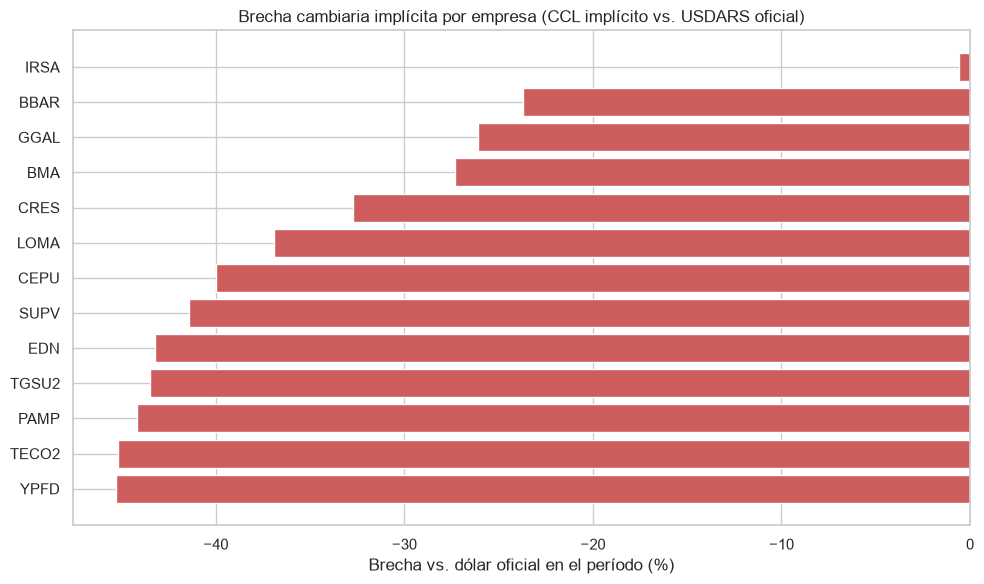

,ticker_usd,nombre_empresa,retorno_local_ars_pct,retorno_adr_usd_pct,ccl_implicito_pct,usdars_oficial_pct,brecha_pct
11,IRSA,Irsa,4056.8,172.3,1426.5,1435.5,-0.6
10,BBAR,Bbva,3639.2,219.1,1071.9,1435.5,-23.7
0,GGAL,Grupo Financiero Galicia S.A,3880.5,250.8,1034.6,1435.5,-26.1
1,BMA,Banco Macro,4143.1,279.9,1016.8,1435.5,-27.3
4,CRES,Cresud,2555.5,156.8,934.1,1435.5,-32.7
6,LOMA,Loma Negra Compañia Industrial Argentina Sa,1202.0,34.3,869.4,1435.5,-36.9
12,CEPU,Central Puerto Sa,3265.3,265.0,822.0,1435.5,-40.0
5,SUPV,Grupo Supervielle S.A,2597.0,199.6,800.3,1435.5,-41.4
7,EDN,Edenor,2465.1,194.1,772.2,1435.5,-43.2
8,TGSU2,Transportadora Gas Del Sur,4160.4,391.4,767.1,1435.5,-43.5


In [5]:
ADR_MAP = {
    "GGAL": "GGAL", "BMA": "BMA", "YPFD": "YPF", "PAMP": "PAM", "CRES": "CRESY", "SUPV": "SUPV",
    "LOMA": "LOMA", "EDN": "EDN", "TGSU2": "TGS", "TECO2": "TEO", "BBAR": "BBAR", "IRSA": "IRS", "CEPU": "CEPU",
}
CACHE_ADR = Path("../cache/adr_argentina")
CACHE_ADR.mkdir(parents=True, exist_ok=True)


def obtener_adr(adr_ticker: str) -> pd.DataFrame:
    path = CACHE_ADR / f"{adr_ticker}.csv"
    if path.exists() and pd.Timestamp.fromtimestamp(path.stat().st_mtime).date() == pd.Timestamp.today().date():
        return pd.read_csv(path, parse_dates=["Date"])
    h = yf.Ticker(adr_ticker).history(period="5y", auto_adjust=False).reset_index()[["Date", "Close"]]
    h.to_csv(path, index=False)
    time.sleep(1.2)
    return h


adr_frames = []
for loc, adr in ADR_MAP.items():
    h = obtener_adr(adr)
    h["local_ticker"] = loc
    h["fecha"] = pd.to_datetime(h["Date"], utc=True).dt.tz_localize(None).dt.normalize()
    adr_frames.append(h[["local_ticker", "fecha", "Close"]].rename(columns={"Close": "adr_close"}))
adr_precios = pd.concat(adr_frames, ignore_index=True)

local_precios = con.execute(
    "SELECT ticker_usd AS local_ticker, fecha, adj_close AS local_close FROM fact_precios_daily "
    "WHERE ticker_usd = ANY(?) AND adj_close IS NOT NULL",
    [list(ADR_MAP.keys())],
).fetchdf()
local_precios["fecha"] = pd.to_datetime(local_precios["fecha"])

usdars = con.execute("SELECT fecha, valor FROM fact_macro_daily WHERE serie = 'USDARS'").fetchdf()
usdars["fecha"] = pd.to_datetime(usdars["fecha"])

filas = []
for loc, adr in ADR_MAP.items():
    lp = local_precios[local_precios.local_ticker == loc].sort_values("fecha")
    ap = adr_precios[adr_precios.local_ticker == loc].sort_values("fecha")
    inicio = max(lp.fecha.min(), ap.fecha.min(), usdars.fecha.min())
    fin = min(lp.fecha.max(), ap.fecha.max(), usdars.fecha.max())
    lp_w = lp[(lp.fecha >= inicio) & (lp.fecha <= fin)]
    ap_w = ap[(ap.fecha >= inicio) & (ap.fecha <= fin)]
    u_w = usdars[(usdars.fecha >= inicio) & (usdars.fecha <= fin)]
    if lp_w.empty or ap_w.empty or u_w.empty:
        continue
    g_local = lp_w.local_close.iloc[-1] / lp_w.local_close.iloc[0]
    g_adr = ap_w.adr_close.iloc[-1] / ap_w.adr_close.iloc[0]
    g_ccl_implicito = g_local / g_adr
    g_usdars = u_w.valor.iloc[-1] / u_w.valor.iloc[0]
    filas.append({
        "ticker_usd": loc, "adr": adr,
        "retorno_local_ars_pct": round((g_local - 1) * 100, 1),
        "retorno_adr_usd_pct": round((g_adr - 1) * 100, 1),
        "ccl_implicito_pct": round((g_ccl_implicito - 1) * 100, 1),
        "usdars_oficial_pct": round((g_usdars - 1) * 100, 1),
        "brecha_pct": round((g_ccl_implicito / g_usdars - 1) * 100, 1),
    })

brecha = pd.DataFrame(filas).merge(dim_arg[["ticker_usd", "nombre_empresa"]], on="ticker_usd")
brecha = brecha.sort_values("brecha_pct", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["indianred" if v < 0 else "seagreen" for v in brecha["brecha_pct"]]
ax.barh(brecha["ticker_usd"], brecha["brecha_pct"], color=colors)
ax.axvline(0, color="grey", linewidth=0.8)
ax.set_xlabel("Brecha vs. dólar oficial en el período (%)")
ax.set_title("Brecha cambiaria implícita por empresa (CCL implícito vs. USDARS oficial)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

brecha[["ticker_usd", "nombre_empresa", "retorno_local_ars_pct", "retorno_adr_usd_pct", "ccl_implicito_pct", "usdars_oficial_pct", "brecha_pct"]]

## 5. Ranking final

Cruza checklist de Lynch, valuación vs. sector real, y (donde aplica) la brecha cambiaria implícita.

In [6]:
ranking = (
    lynch_arg[["ticker_usd", "nombre_empresa", "lynch_categoria_auto", "lynch_checklist_score", "lynch_valuacion_peg"]]
    .merge(comparables_arg[["ticker_usd", "comp_pe_vs_sector_pct", "comp_percentil_crecimiento_en_sector"]], on="ticker_usd")
    .merge(brecha[["ticker_usd", "brecha_pct"]], on="ticker_usd", how="left")
    .sort_values(["lynch_checklist_score", "comp_pe_vs_sector_pct"], ascending=[False, True])
)
ranking

,ticker_usd,nombre_empresa,lynch_categoria_auto,lynch_checklist_score,lynch_valuacion_peg,comp_pe_vs_sector_pct,comp_percentil_crecimiento_en_sector,brecha_pct
40,ROSE,Instituto Rosenbusch,Recuperable,4,Sin dato,-97.4,0.0,NaN
47,LONG,Longvie,Recuperable,4,Sin dato,NaN,2.0,NaN
43,IRSA,Irsa,Estable,3,Sin dato,-87.3,20.0,-0.6
62,TXAR,Ternium Argentina Sa,Recuperable,3,Sin dato,-51.0,69.0,NaN
18,CEPU,Central Puerto Sa,Estable,3,Sin dato,-40.7,74.0,-40.0
...,...,...,...,...,...,...,...,...
31,GCDI,Gcdi S.A. Acciones Ord Esc,Recuperable,1,Sin dato,NaN,0.0,NaN
58,SAMI,San Miguel,Recuperable,1,Sin dato,NaN,100.0,NaN
55,PAMP,Pampa Energía,Recuperable,0,Sin dato,-64.5,52.0,-44.2
7,BMA,Banco Macro,Recuperable,0,Sin dato,10.4,8.0,-27.3
